In [2]:
from database import postgres_connection
from data_processing_and_visualization import check_column_for_nan, plot_histograms, plot_bars

import pandas as pd

In [3]:
"""
Выгрузка из БД с помощью SQL.
На текущий момент выгрузка реализована с помощью DVC
"""
# QUERY_FEEDS = """
# SELECT *
# FROM feed_data
# WHERE ACTION = 'view'
# ORDER BY timestamp DESC
# LIMIT 2500000
# """

# with postgres_connection() as conn:
#     feeds_df = pd.read_sql(QUERY_FEEDS, conn)

'\nВыгрузка из БД с помощью SQL.\nНа текущий момент выгрузка реализована с помощью DVC\n'

In [4]:
feeds_df = pd.read_parquet('data/feeds_df_half.parquet')

In [5]:
feeds_df

,timestamp,user_id,post_id,action,target
0,2021-12-29 23:51:06,71338,5079,view,0
1,2021-12-29 23:51:06,57667,712,view,0
2,2021-12-29 23:51:06,64493,3096,view,0
3,2021-12-29 23:51:06,50842,5720,view,0
4,2021-12-29 23:51:06,147682,6676,view,0
...,...,...,...,...,...
2499995,2021-12-26 19:30:20,115674,2433,view,0
2499996,2021-12-26 19:30:20,152105,3873,view,0
2499997,2021-12-26 19:30:20,43762,1706,view,0
2499998,2021-12-26 19:30:20,156484,3069,view,0


In [6]:
user_features_df = pd.read_parquet('data/user_features.parquet')
post_features_df = pd.read_parquet('data/post_features.parquet')
df_holiday = pd.read_parquet('data/df_holiday.parquet')

# EDA

In [7]:
for col in feeds_df.columns:
    check_column_for_nan(feeds_df, col)

Столбец 'timestamp' не содержит NaN
Столбец 'user_id' не содержит NaN
Столбец 'post_id' не содержит NaN
Столбец 'action' не содержит NaN
Столбец 'target' не содержит NaN


### A. Извлечение фичей из времени

In [8]:
df_final = feeds_df.merge(user_features_df[['user_id', 'country']], on='user_id', how='left')

In [9]:
class TimeFeatureExtractor:
    """Класс для добавления временных фичей к DataFrame."""
    
    def __init__(self, df: pd.DataFrame):
        """
        Инициализация extractor с копированием DataFrame.
        
        Параметры:
            df: исходный DataFrame (со столбцами 'timestamp' и 'country')
        """
        self.df = df.copy()
        self._prepared = False
        self._median_sec = 97
    
    def _prepare_df(self, timestamp_col: str = 'timestamp'):
        """Приводит timestamp к datetime и извлекает дату (вызывается один раз)."""
        if self._prepared:
            return
        
        self.df[timestamp_col] = pd.to_datetime(self.df[timestamp_col])
        self._prepared = True
    
    def add_holiday_flags(self, df_holiday: pd.DataFrame, timestamp_col: str = 'timestamp') -> pd.DataFrame:
        """
        Добавляет столбцы is_holiday к сохранённому df.

        Параметры:
            df_holiday: DataFrame со столбцами 'date' и 'country' (праздники)

        Возвращает:
            DataFrame с добавленными столбцами 'is_holiday'
        """
        # Подготовка df (timestamp -> datetime, извлечение date)
        self._prepare_df()
        
        df_with_date = self.df.copy()
        df_with_date['date'] = pd.to_datetime(df_with_date[timestamp_col]).dt.date
        
        df_holiday = df_holiday.copy()
        df_holiday['date'] = pd.to_datetime(df_holiday['date']).dt.date

        # Определяем is_holiday = 1
        merged = df_with_date.merge(
            df_holiday[['country', 'date']],
            on=['country', 'date'],
            how='left',
            indicator=True
        )
        
        merged['is_holiday'] = (merged['_merge'] == 'both').astype(int)

        # Убираем служебные колонки
        merged = merged.drop(columns=['_merge', 'date'])

        self.df = merged
        
        return self.df
    
    def add_time_of_day(self, timestamp_col: str = 'timestamp') -> pd.DataFrame:
        """
        Добавим столбец с разбиением на время суток.

        Возвращает:
            DataFrame с добавленными столбцами 'time_of_day'
        """
        self._prepare_df()
            
        bins = [0, 6, 12, 18, 24]
        labels = ['night', 'morning', 'day', 'evening']

        self.df['time_of_day'] = pd.cut(self.df[timestamp_col].dt.hour, bins=bins, labels=labels, right=True, include_lowest=True)

        return self.df
    
    def add_time_features(self, timestamp_col: str = 'timestamp') -> pd.DataFrame:
        """
        Добавляет базовые временные фичи из datetime столбца.

        Параметры:
            date_col: имя datetime столбца (по умолчанию 'timestamp')

        Возвращает:
            DataFrame с добавленными временными фичами
        """
        self._prepare_df()
        
        self.df['year'] = self.df[timestamp_col].dt.year
        self.df['month'] = self.df[timestamp_col].dt.month
        self.df['is_month_start'] = self.df[timestamp_col].dt.is_month_start.astype(int)
        self.df['is_month_end'] = self.df[timestamp_col].dt.is_month_end.astype(int)
        self.df['is_weekend'] = self.df[timestamp_col].dt.dayofweek.isin([5, 6]).astype(int)
        
        return self.df
    
    def add_time_since_last_interaction(self, timestamp_col='timestamp', user_id_col='user_id'):
        """
        Добавляет время до предыдущего взаимодействия в секундах.

        Возвращает:
            DataFrame с добавленным столбцом 'time_since_last_interaction_sec'
        """
        
        self._prepare_df()
        
        # Сортируем по user_id и timestamp
        self.df = self.df.sort_values([user_id_col, timestamp_col])
        
        # Вычисляем разницу между текущим и предыдущим timestamp для каждого пользователя
        self.df['time_since_last_interaction_sec'] = self.df.groupby(user_id_col)[timestamp_col].diff().dt.total_seconds()

        # Заполняем NaN медианой в обоих
        self.df['time_since_last_interaction_sec'] = self.df['time_since_last_interaction_sec'].fillna(self._median_sec)
        
        return self.df
    
    def get_df(self) -> pd.DataFrame:
        """Возвращает текущий (возможно модифицированный) DataFrame."""
        
        return self.df


In [10]:
extractor = TimeFeatureExtractor(df_final)
extractor.add_time_features()
extractor.add_holiday_flags(df_holiday)
extractor.add_time_of_day()
extractor.add_time_since_last_interaction()

df_final = extractor.get_df()
df_final = df_final.drop('country', axis=1)

In [11]:
df_final

,timestamp,user_id,post_id,action,target,year,month,is_month_start,is_month_end,is_weekend,is_holiday,time_of_day,time_since_last_interaction_sec
398211,2021-12-29 14:50:01,200,6087,view,0,2021,12,0,0,0,0,day,97.0
397888,2021-12-29 14:50:37,200,3895,view,0,2021,12,0,0,0,0,day,36.0
396787,2021-12-29 14:52:07,200,4423,view,0,2021,12,0,0,0,0,day,90.0
394822,2021-12-29 14:55:04,200,4200,view,1,2021,12,0,0,0,0,day,177.0
393680,2021-12-29 14:56:54,200,3232,view,0,2021,12,0,0,0,0,day,110.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1457892,2021-12-28 08:23:25,168547,3731,view,0,2021,12,0,0,0,0,morning,83.0
1455860,2021-12-28 08:25:25,168547,3260,view,0,2021,12,0,0,0,0,morning,120.0
1454266,2021-12-28 08:27:19,168547,2650,view,0,2021,12,0,0,0,0,morning,114.0
1452855,2021-12-28 08:28:43,168547,5562,view,0,2021,12,0,0,0,0,morning,84.0


In [12]:
columns_to_convert = ['target', 'month', 'year']
df_final[columns_to_convert] = df_final[columns_to_convert].astype(object)

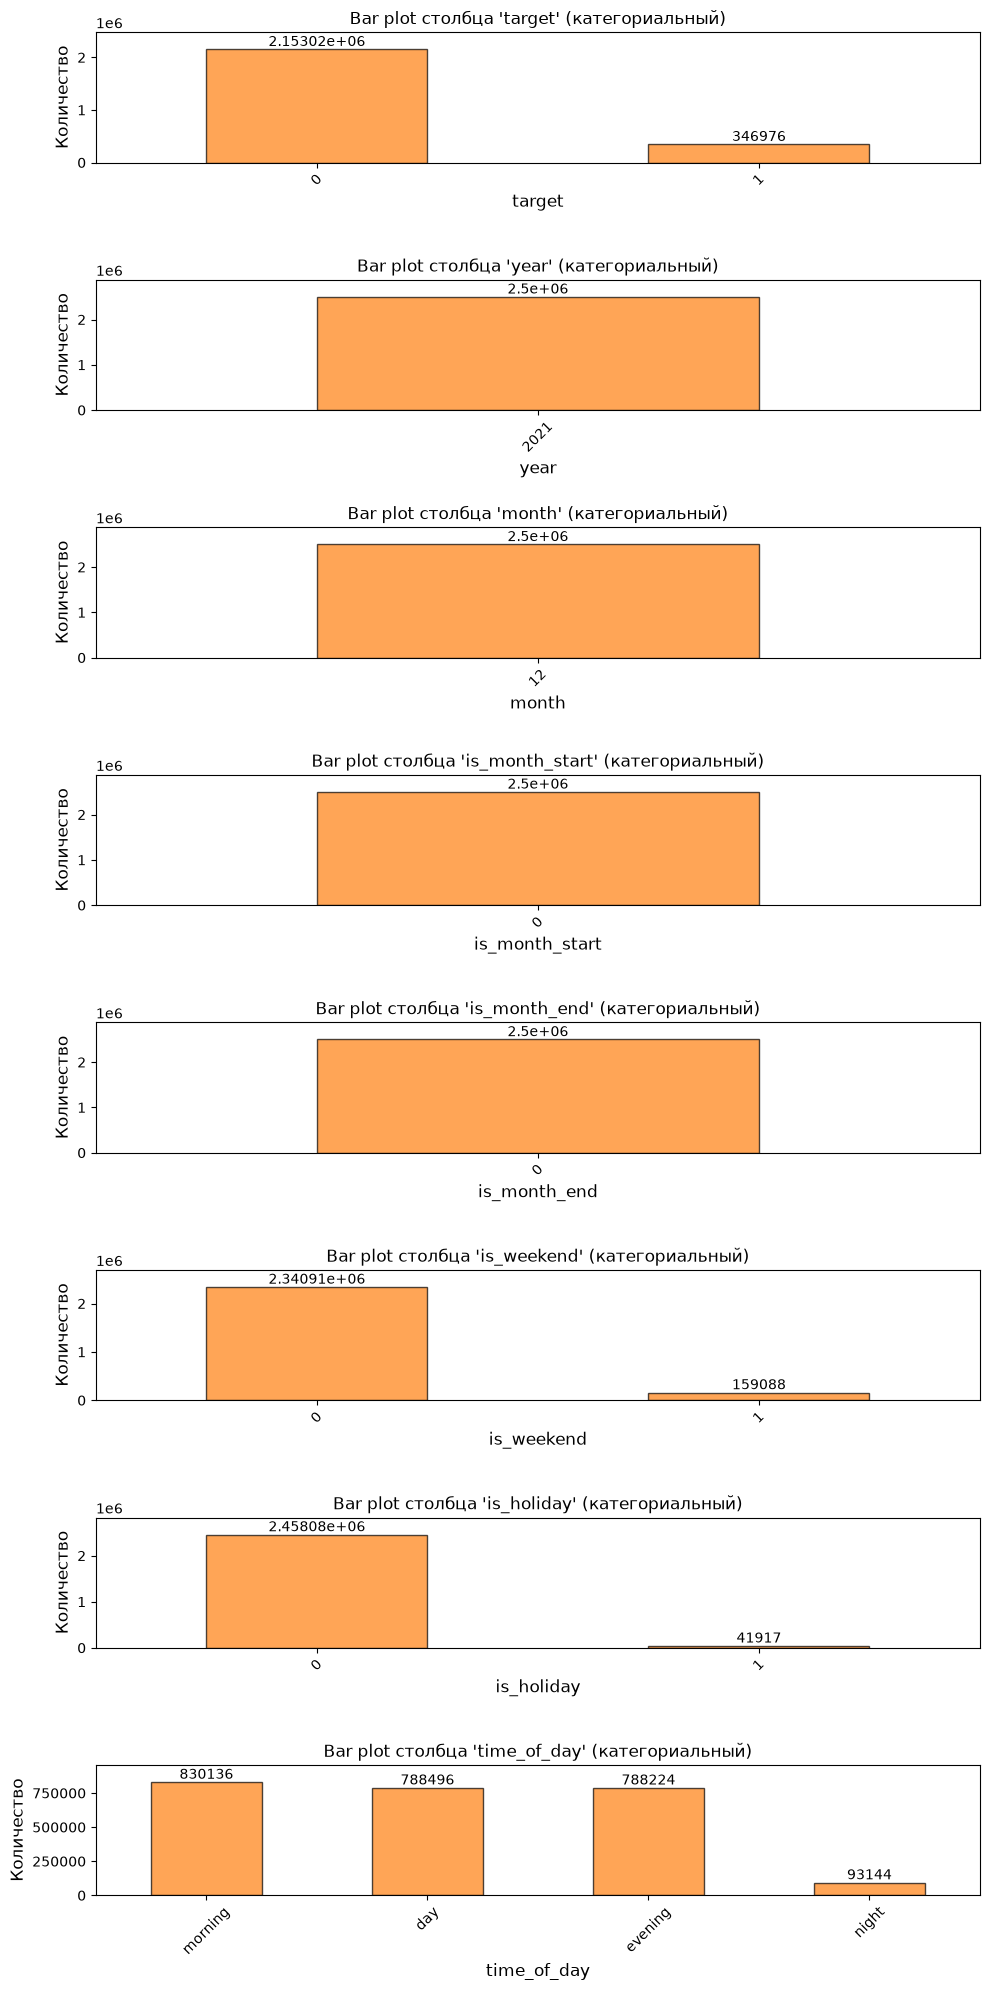

In [13]:
plot_bars(df_final, list(filter(lambda x: x not in ['timestamp', 'user_id', 'post_id', 'action', 'time_since_last_interaction_sec'], df_final.columns)), bins=20, figsize = (10, 20))

### A. Выводы:
1) Фичи с флагами ожидаемо имеют сильно смещение
2) Ввиду того, что данные практически не охватывает все месяца, фича будет удалена
3) Фичу год необходимо удалить, т.к. имеет константное значение

In [14]:
df_final = df_final.drop(['year', 'month', 'is_month_start', 'is_month_end'], axis=1)

In [15]:
df_final = df_final.merge(user_features_df, on='user_id', how='left')
df_final = df_final.merge(post_features_df, on='post_id', how='left')

In [16]:
int_cols = df_final.select_dtypes(include="int64").columns
float_cols = df_final.select_dtypes(include="float64").columns

df_final[int_cols] = df_final[int_cols].astype("int32")
df_final[float_cols] = df_final[float_cols].astype("float32")

In [17]:
# Разделение по дате (80% train, 20% test)
split_date = df_final['timestamp'].quantile(0.8)

df_train = df_final[df_final['timestamp'] < split_date].copy()
df_test = df_final[df_final['timestamp'] >= split_date].copy()

# EDA ОБУЧАЮЩЕГО ДАТАСЕТА

In [18]:
df_train

,timestamp,user_id,post_id,action,target,is_weekend,is_holiday,time_of_day,time_since_last_interaction_sec,gender,...,tfidf_svd_90,tfidf_svd_91,tfidf_svd_92,tfidf_svd_93,tfidf_svd_94,tfidf_svd_95,tfidf_svd_96,tfidf_svd_97,tfidf_svd_98,tfidf_svd_99
26,2021-12-29 07:51:56,201,4357,view,1,0,0,morning,97.0,0,...,-0.005733,0.005099,0.059669,0.020117,-0.001215,0.039574,0.020125,0.025479,0.010226,0.009838
27,2021-12-29 07:53:05,201,6067,view,1,0,0,morning,69.0,0,...,-0.002405,-0.022386,-0.023300,0.020957,0.001846,-0.022517,-0.000325,0.004938,-0.017299,0.004722
28,2021-12-29 07:53:32,201,6214,view,0,0,0,morning,27.0,0,...,-0.020424,-0.002950,0.030437,0.018833,0.028323,0.023835,0.029641,-0.031850,-0.051845,-0.025854
29,2021-12-29 07:54:41,201,3180,view,0,0,0,morning,69.0,0,...,-0.006347,0.014601,-0.002675,0.007849,-0.000322,-0.005964,0.011082,-0.021204,0.004676,-0.005801
30,2021-12-29 07:57:14,201,5299,view,1,0,0,morning,153.0,0,...,-0.018060,0.015878,0.036527,0.003931,-0.036788,0.032316,-0.023808,-0.045321,0.005044,0.008968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499995,2021-12-28 08:23:25,168547,3731,view,0,0,0,morning,83.0,1,...,0.032549,-0.031565,0.017088,-0.027702,-0.014237,0.010191,-0.002761,-0.036835,-0.003797,0.017898
2499996,2021-12-28 08:25:25,168547,3260,view,0,0,0,morning,120.0,1,...,-0.034205,0.014612,-0.001029,0.000534,-0.003525,0.013680,0.030384,0.032186,0.001746,-0.007923
2499997,2021-12-28 08:27:19,168547,2650,view,0,0,0,morning,114.0,1,...,0.045049,0.034295,0.005937,-0.035138,0.002294,-0.023768,-0.000538,0.053187,-0.017187,0.074805
2499998,2021-12-28 08:28:43,168547,5562,view,0,0,0,morning,84.0,1,...,0.001893,0.046347,0.014551,0.015364,0.017991,0.019439,0.001221,-0.050147,-0.003471,-0.042674


In [19]:
df_train[['time_since_last_interaction_sec', 'age', 'text_len', 'avg_word_len']].describe()

,time_since_last_interaction_sec,age,text_len,avg_word_len
count,1.999984e+06,1.999984e+06,1.999984e+06,1.999984e+06
mean,6.156003e+02,2.721717e+01,1.364712e+03,6.157823e+00
std,7.793154e+03,1.026927e+01,1.317038e+03,1.105314e+00
min,1.000000e+01,1.400000e+01,3.000000e+01,4.538462e+00
25%,5.300000e+01,1.900000e+01,2.620000e+02,5.565217e+00
50%,9.700000e+01,2.400000e+01,1.075000e+03,5.840336e+00
75%,1.360000e+02,3.300000e+01,1.978000e+03,6.227891e+00
max,2.271040e+05,9.500000e+01,2.539200e+04,1.857143e+01


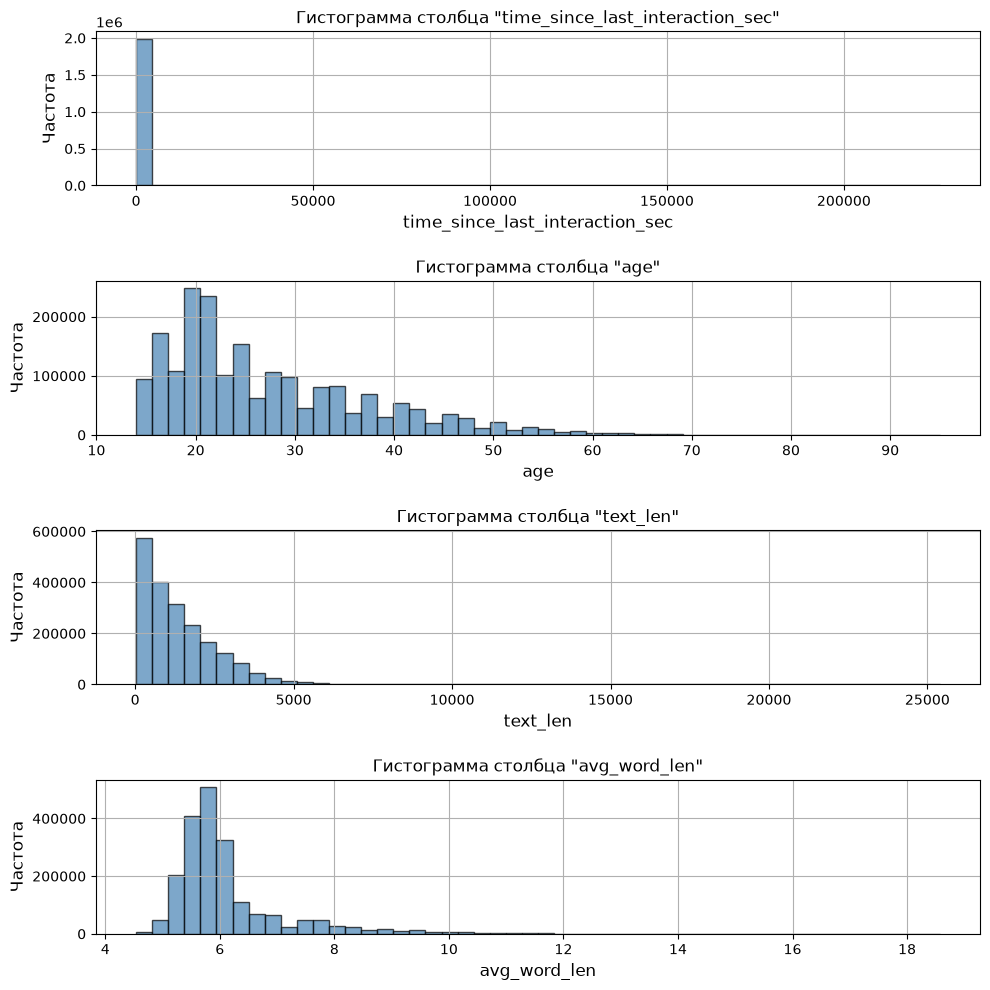

In [20]:
plot_histograms(df_train, ['time_since_last_interaction_sec', 'age', 'text_len', 'avg_word_len', 'freq_city', 'freq_city_in_country'], bins=50, figsize = (10, 10))

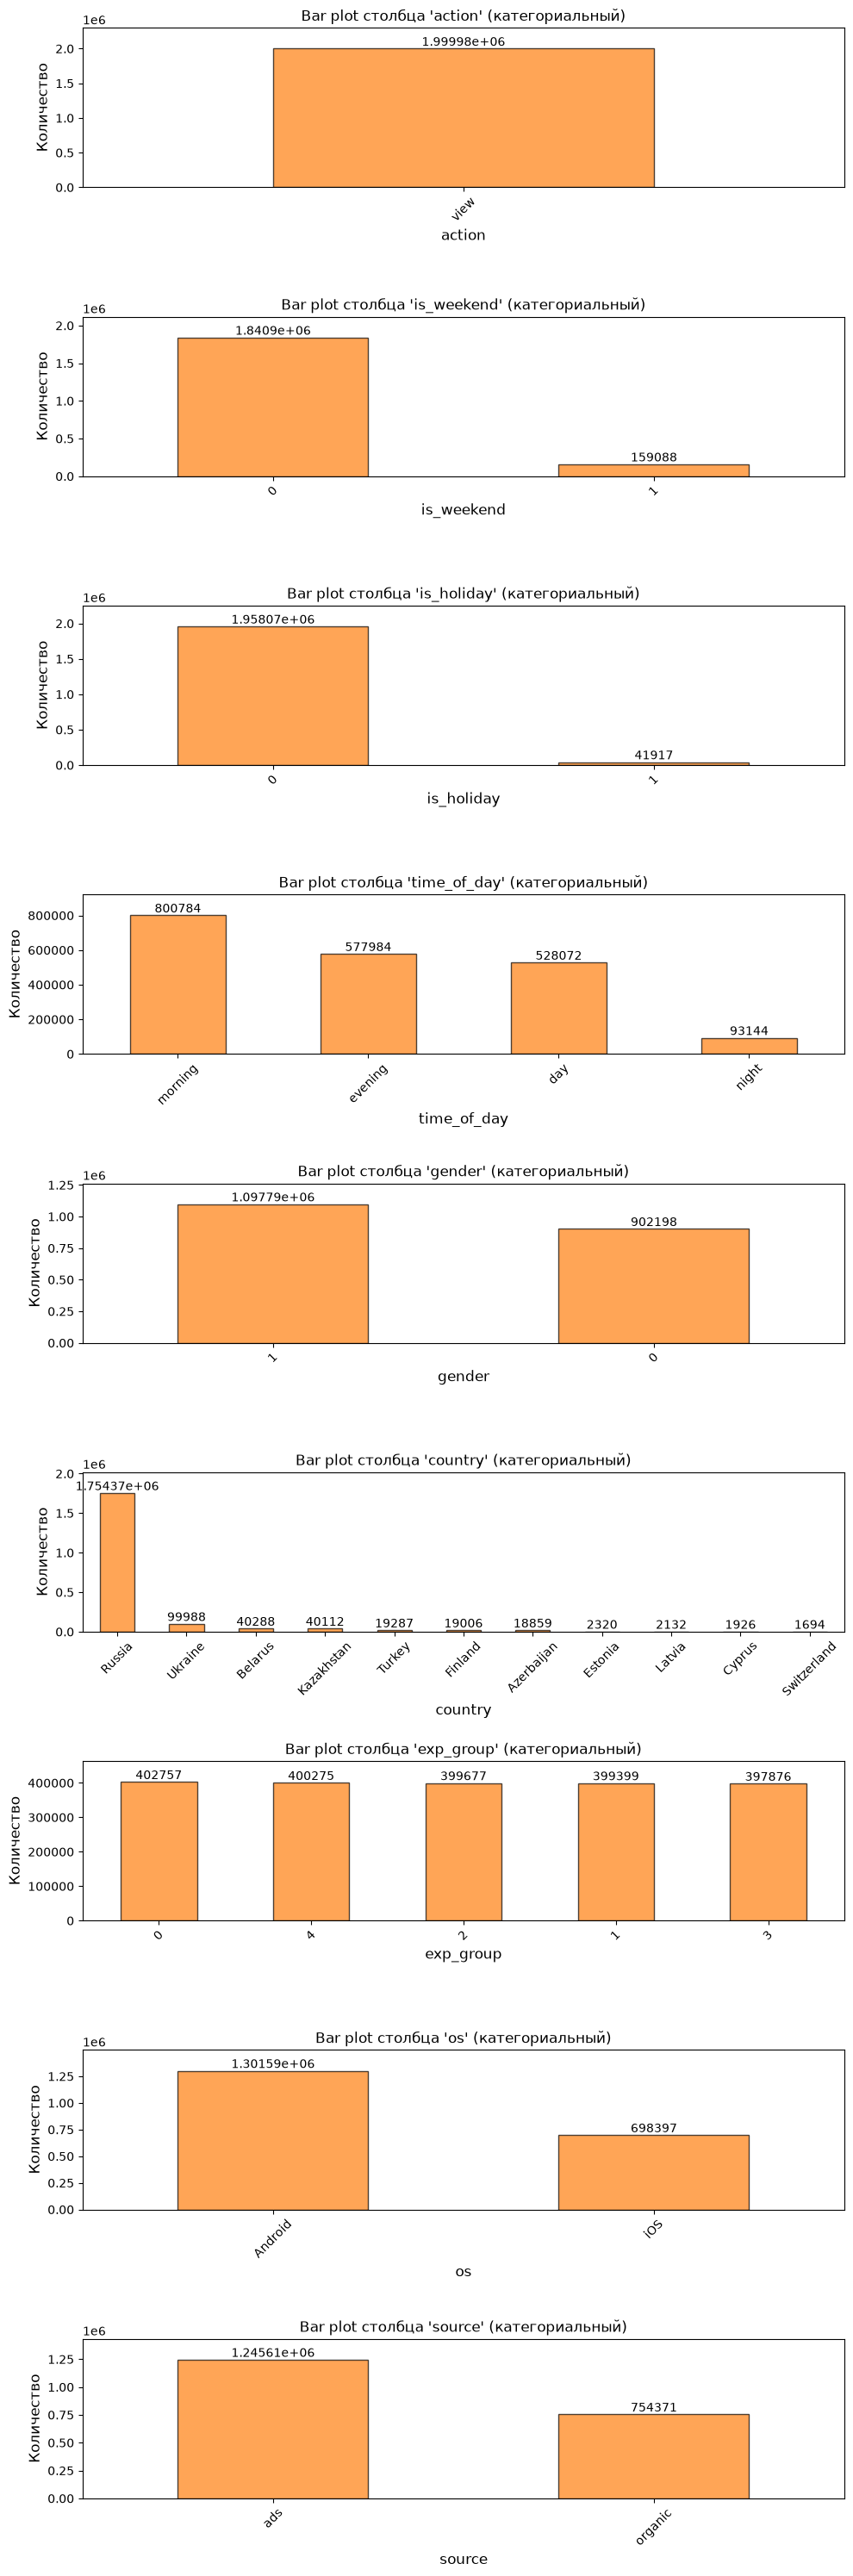

In [21]:
plot_bars(df_train, ['action', 'is_weekend', 'is_holiday', 'time_of_day', 'gender', 'country', 'exp_group', 'os', 'source'], bins=20, figsize = (10, 30))

### Вывод
Все фичи преобладают не в константном значении в обучающем датасете

In [22]:
features_columns = [col for col in df_train.columns if col not in ['timestamp', 'user_id', 'post_id', 'target', 'action']]

target_column = 'target'

In [23]:
X_train, y_train = df_train[features_columns], df_train[[target_column]]
X_test, y_test = df_test[features_columns], df_test[[target_column]]

In [24]:
X_train.to_parquet("data/X_train_half.parquet", compression='snappy')
y_train.to_parquet("data/y_train_half.parquet", compression='snappy')

X_test.to_parquet("data/X_test_half.parquet", compression='snappy')
y_test.to_parquet("data/y_test_half.parquet", compression='snappy')